In [52]:
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Import plotting functions from graphs.py
from graphs import (
    load_runs,
    plot_requests_per_second,
    plot_batch_times,
    get_requests_per_second,
    _batch_elapsed,
    _build_color_map,
    _collect_model_names,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## Configuration
Select which runs and baselines to load, and toggle display options.

In [59]:
# Directories
BASELINES_DIR = Path("baselines")
RUNS_DIR = Path("runs")

# Display options
INCLUDE_REBALANCE_TIME = False  # include rebalance time in elapsed calculations
SHOW_REBALANCE = False          # show vertical rebalance event lines
SHOW_OPTIMUM = True             # show optimum markers

# Filter runs and baselines (set to None to load all, or a list like ["run20", "run21"])
SELECTED_RUNS = ['run24', 'run25']
SELECTED_BASELINES = ['tensor_parallel', 'gpipe_4x8']

In [60]:
# Load data
all_baselines = load_runs(BASELINES_DIR)
all_runs = load_runs(RUNS_DIR)

if SELECTED_RUNS is not None:
    runs = {k: v for k, v in all_runs.items() if k in SELECTED_RUNS}
else:
    runs = all_runs

if SELECTED_BASELINES is not None:
    baselines = {k: v for k, v in all_baselines.items() if k in SELECTED_BASELINES}
else:
    baselines = all_baselines

print(f"Loaded {len(baselines)} baselines: {list(baselines.keys())}")
print(f"Loaded {len(runs)} runs: {list(runs.keys())}")

Loaded 2 baselines: ['gpipe_4x8', 'tensor_parallel']
Loaded 2 runs: ['run24', 'run25']


## Throughput (Requests per Second)

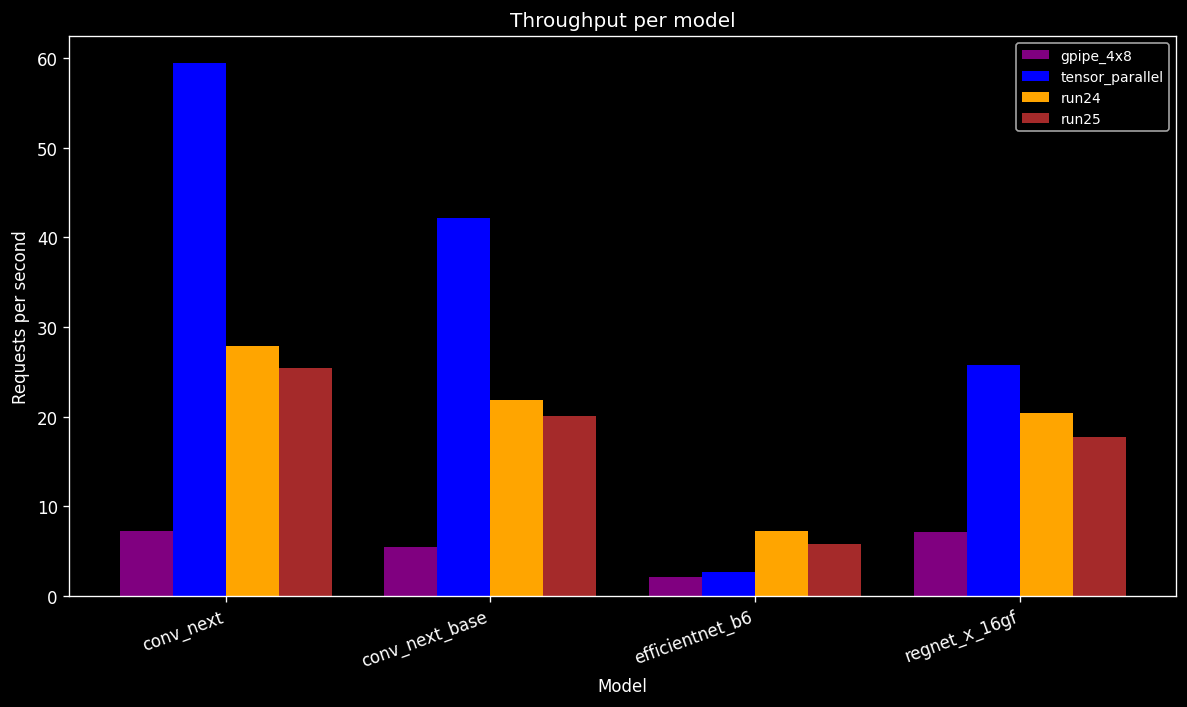

In [61]:
plot_requests_per_second(baselines, runs, include_rebalance=INCLUDE_REBALANCE_TIME)

## Batch Times

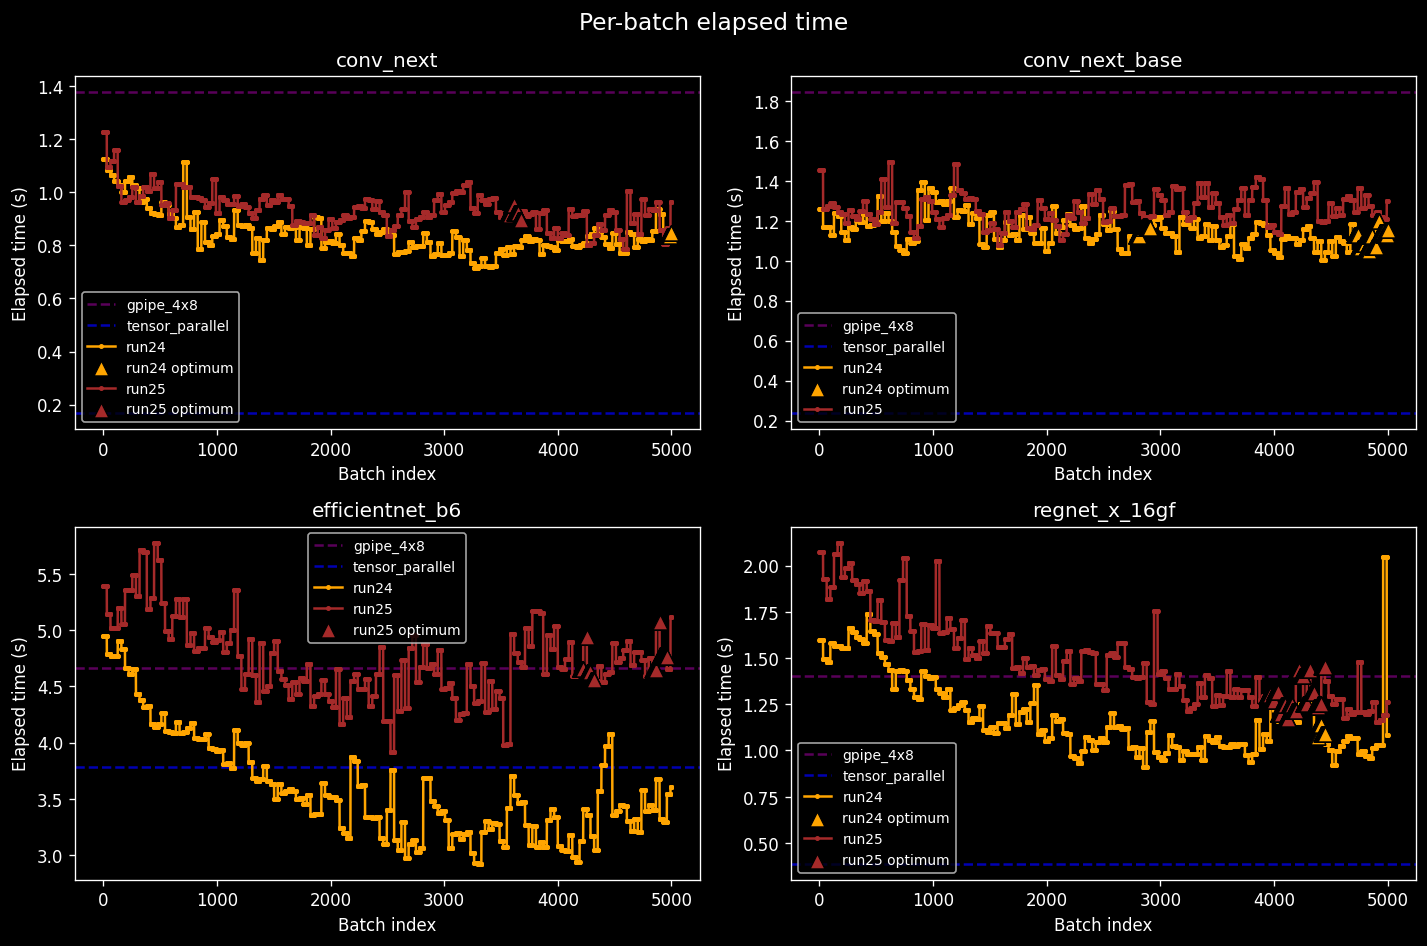

In [62]:
plot_batch_times(
    baselines, runs,
    show_rebalance=SHOW_REBALANCE,
    include_rebalance=INCLUDE_REBALANCE_TIME,
    show_optimum=SHOW_OPTIMUM,
)

## Run Summary Table

In [63]:
for run_name, run_data in sorted(runs.items()):
    meta = run_data.get("meta", {})
    commit = meta.get("git_commit", "?")[:8]
    argv = " ".join(meta.get("argv", [])[1:])
    print(f"=== {run_name} === commit: {commit}")
    print(f"  args: {argv[:100]}")
    for model, result in run_data["results"].items():
        batches = result.get("batches", [])
        rebalances = sum(1 for b in batches if b.get("rebalance", {}).get("did_rebalance", False))
        at_optimum = sum(1 for b in batches if b.get("rebalance", {}).get("at_optimum", False))
        rps = result.get("requests_per_second", 0)
        print(f"  {model}: rps={rps:.2f}, rebalances={rebalances}, at_optimum={at_optimum}")
    print()

=== run24 === commit: 74cc5e80
  args: -n 5000 -b 1 -m 32 --optimizer shisha --rebalance-interval 4 -o ./data/runs
  conv_next: rps=27.83, rebalances=1248, at_optimum=40
  conv_next_base: rps=21.85, rebalances=1184, at_optimum=424
  efficientnet_b6: rps=7.29, rebalances=1248, at_optimum=0
  regnet_x_16gf: rps=20.39, rebalances=1248, at_optimum=128

=== run25 === commit: 8312cb95
  args: -n 5000 -b 1 -m 32 --optimizer shisha --rebalance-interval 4 -o ./data/runs
  conv_next: rps=25.43, rebalances=1248, at_optimum=128
  conv_next_base: rps=20.10, rebalances=1248, at_optimum=0
  efficientnet_b6: rps=5.79, rebalances=1248, at_optimum=256
  regnet_x_16gf: rps=17.75, rebalances=1152, at_optimum=512



## Optimizer State Over Time
Plot deep_gamma and sibling_gamma for runs that include optimizer state data.

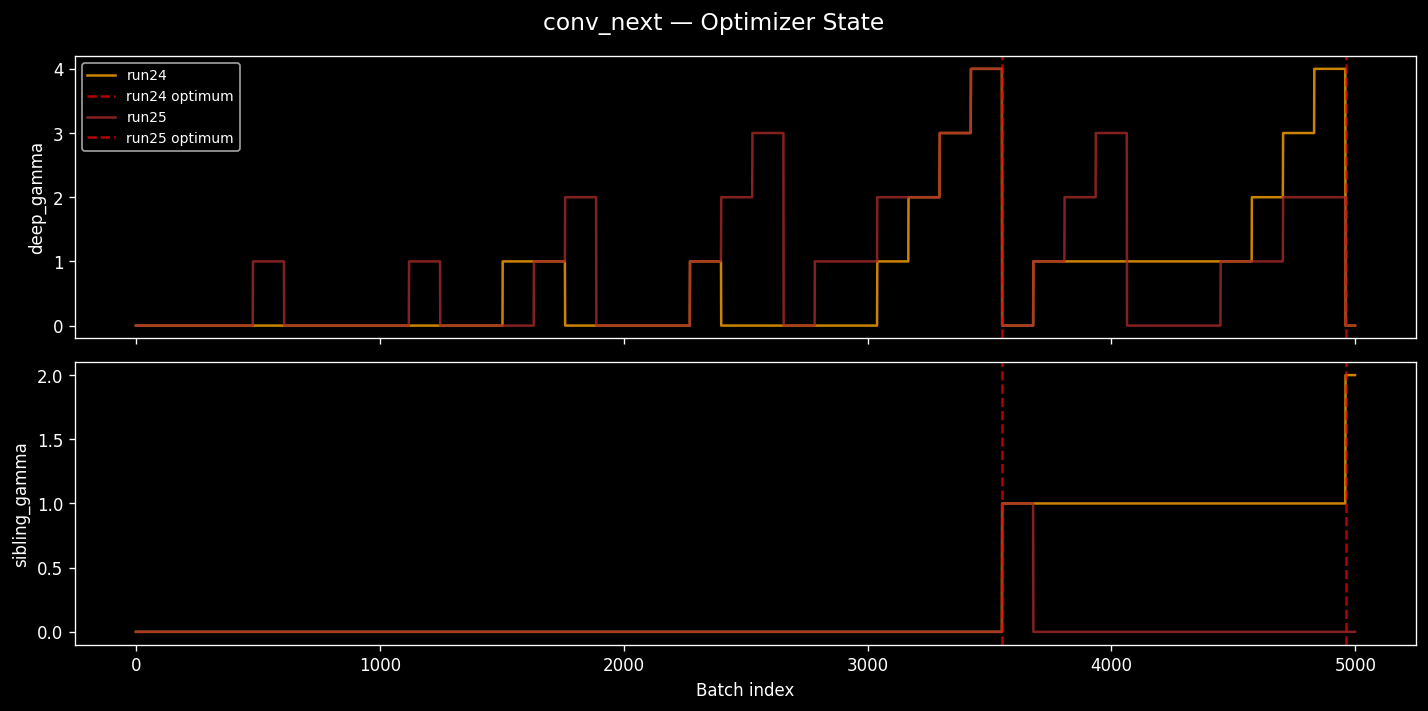

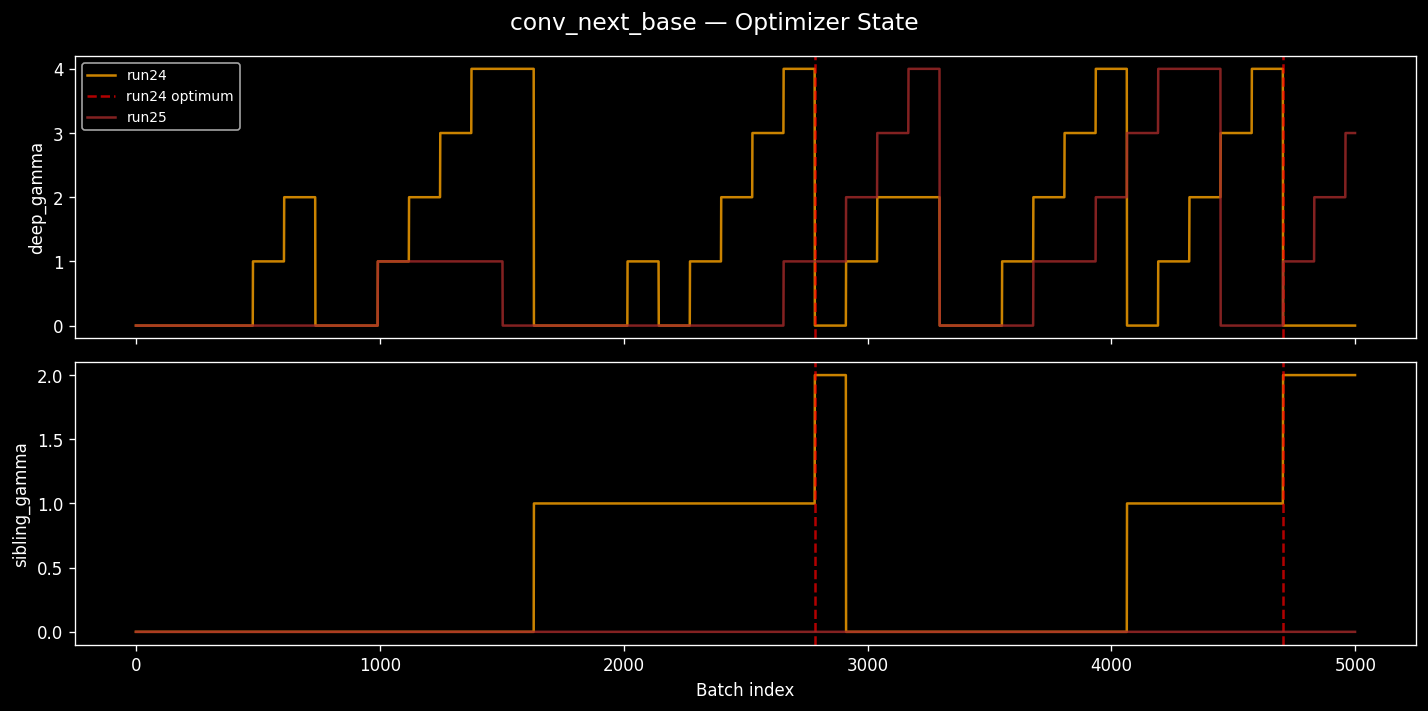

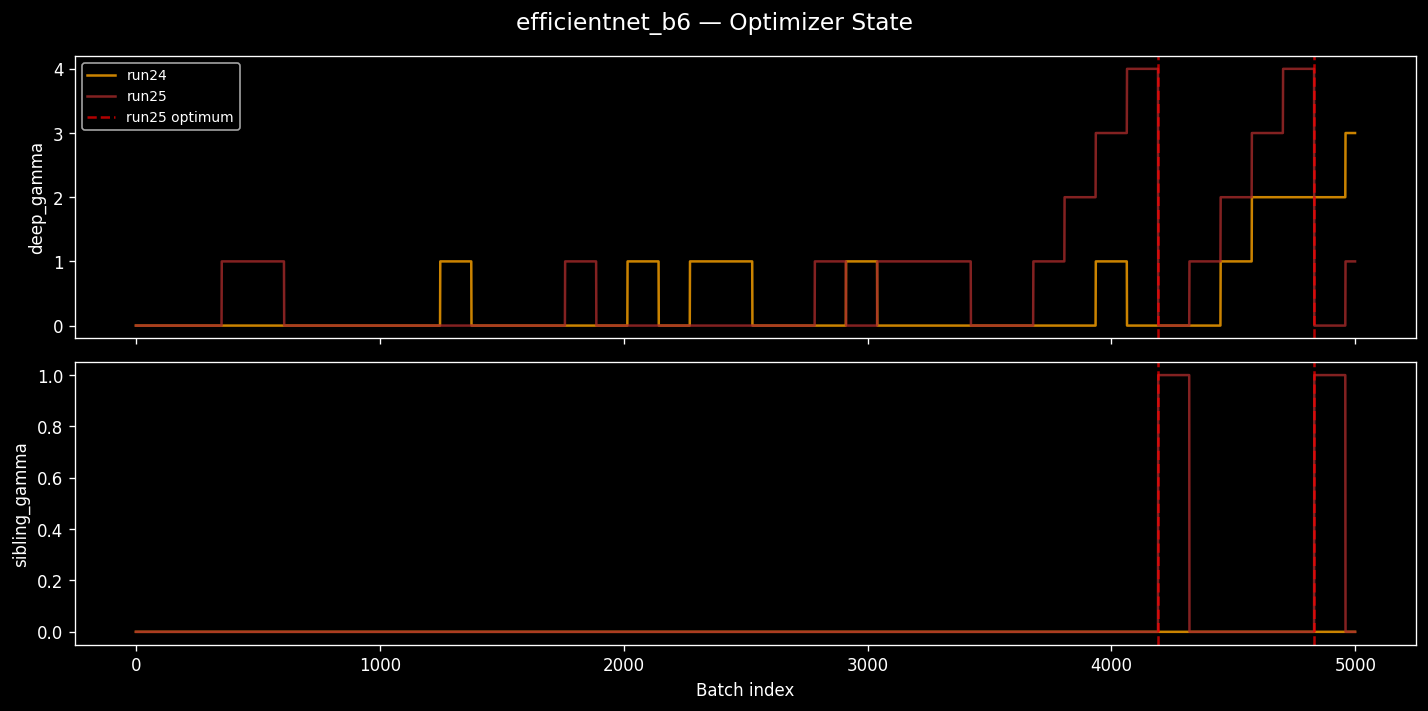

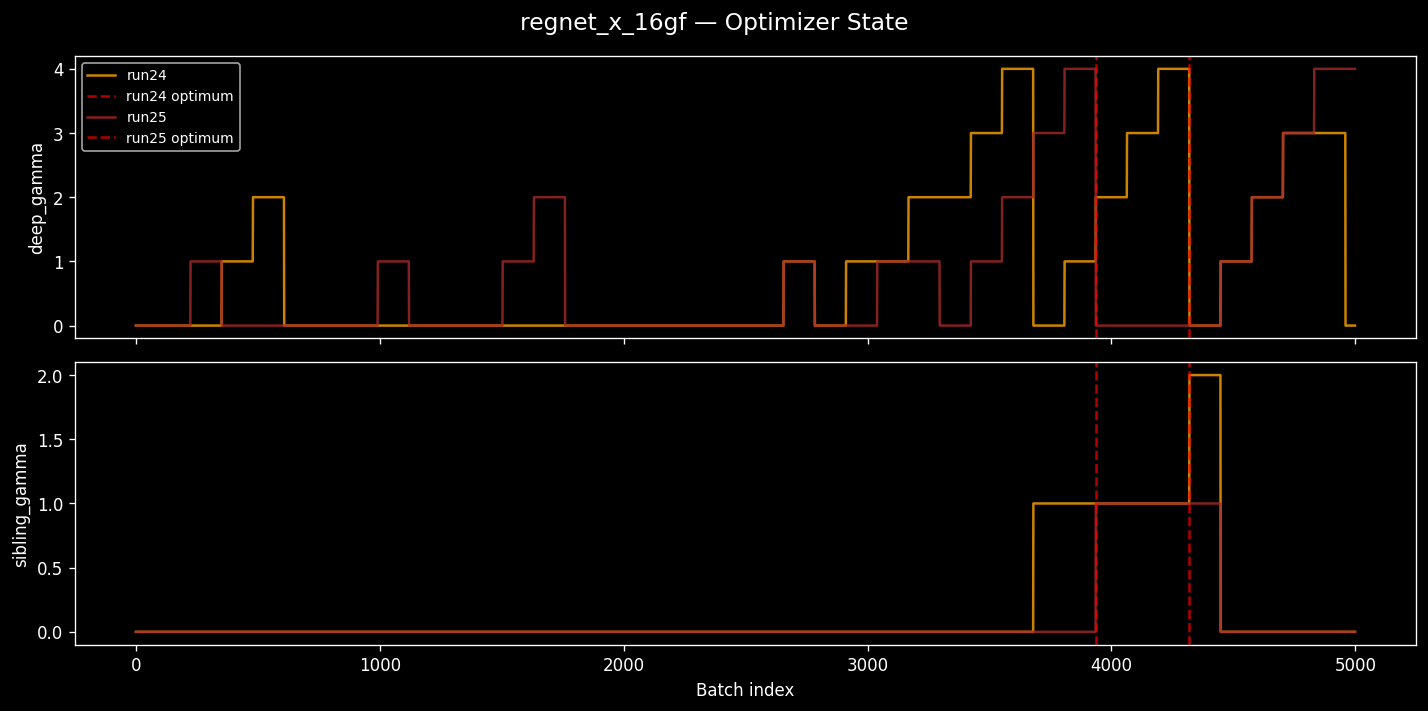

In [64]:
model_names = _collect_model_names(baselines, runs)
colors = _build_color_map(baselines, runs)

for model in model_names:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    fig.suptitle(f"{model} — Optimizer State", fontsize=14)

    for run_name, run_data in runs.items():
        if model not in run_data["results"]:
            continue
        batches = run_data["results"][model].get("batches", [])
        deep_gamma = [b.get("rebalance", {}).get("deep_gamma") for b in batches]
        sibling_gamma = [b.get("rebalance", {}).get("sibling_gamma") for b in batches]

        # Only plot if data exists
        if not any(v is not None for v in deep_gamma):
            continue

        xs = range(len(batches))
        color = colors.get(run_name, "white")
        ax1.plot(xs, deep_gamma, color=color, label=run_name, alpha=0.8, markersize=2)
        ax2.plot(xs, sibling_gamma, color=color, label=run_name, alpha=0.8, markersize=2)

        # Vertical lines where optimum is reached
        optimum_indices = [i for i, b in enumerate(batches)
                          if b.get("rebalance", {}).get("at_optimum", False)]
        if optimum_indices:
            # Find first index of each contiguous optimum block
            optimum_starts = [optimum_indices[0]]
            for j in range(1, len(optimum_indices)):
                if optimum_indices[j] != optimum_indices[j-1] + 1:
                    optimum_starts.append(optimum_indices[j])
            for j, idx in enumerate(optimum_starts):
                label = f"{run_name} optimum" if j == 0 else None
                ax1.axvline(idx, color="red", linestyle="--", alpha=0.7, linewidth=1.5, label=label)
                ax2.axvline(idx, color="red", linestyle="--", alpha=0.7, linewidth=1.5)

    ax1.set_ylabel("deep_gamma")
    ax1.legend(fontsize="small")
    ax2.set_ylabel("sibling_gamma")
    ax2.set_xlabel("Batch index")
    fig.tight_layout()
    plt.show()